# Código original

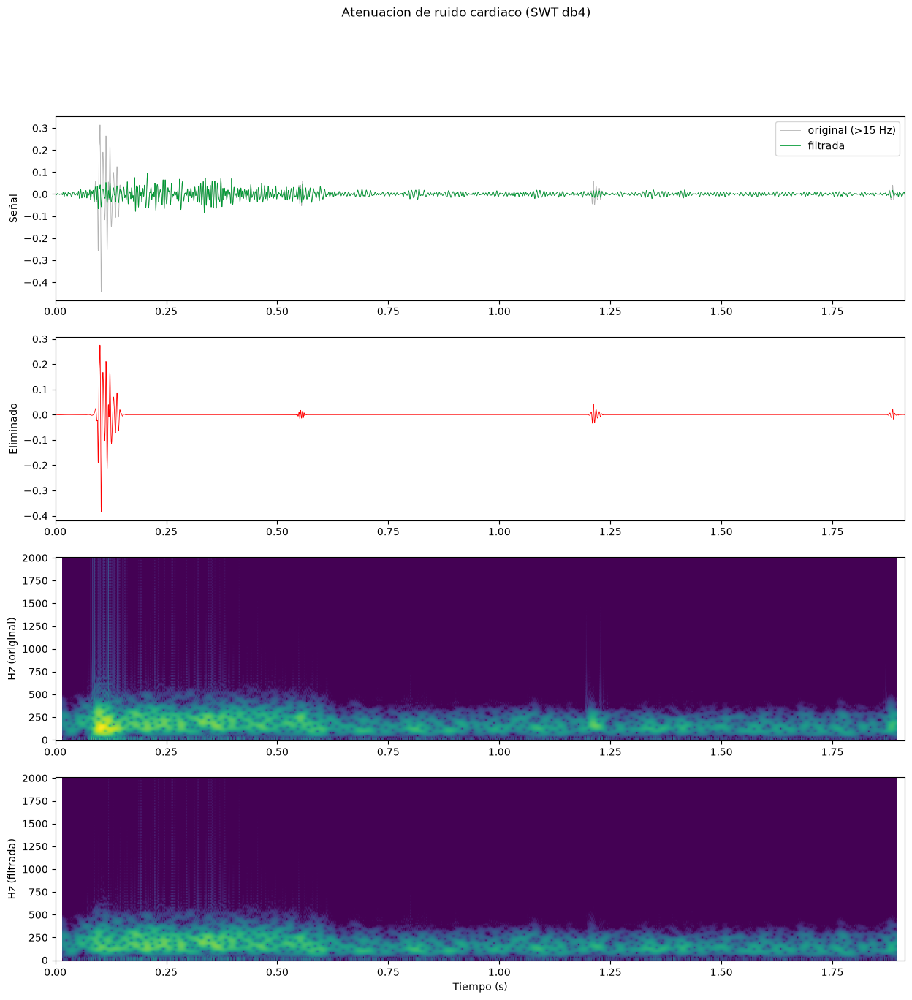

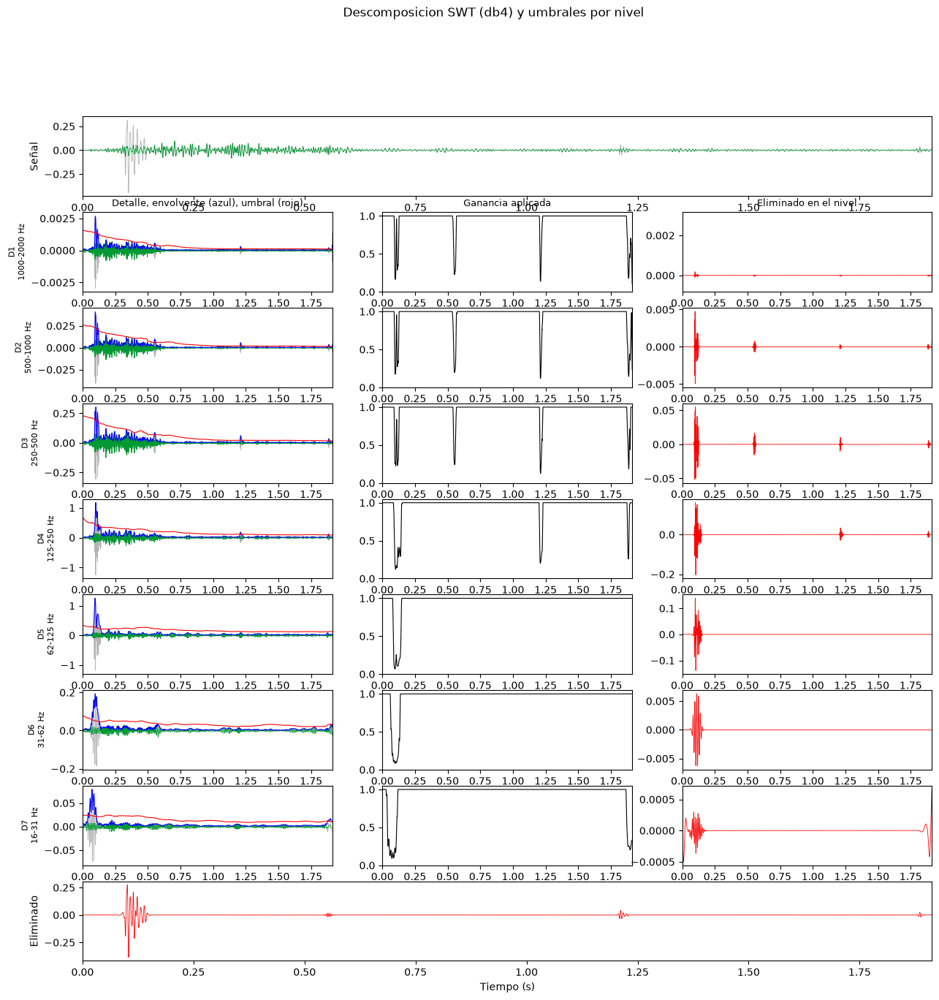

In [1]:
"""
soundwaveletSWT  Atenua los ruidos cardiacos en el sonido respiratorio

    y = soundwaveletSWT(x, fs)
    y, mascara = soundwaveletSWT(x, fs, dibujar)

    Version en Python de soundwaveletSWT.m. Se han mantenido los mismos
    nombres de variables para poder comparar linea a linea con MATLAB.

    Descompone la señal con la SWT (db4) hasta que la aproximacion queda por
    debajo de unos 15 Hz. En cada nivel se calcula la envolvente del detalle y
    se compara con un nivel de referencia, que es la mediana de la envolvente
    entre 0.1 y 0.4 s a cada lado de la muestra. La zona central se deja fuera
    para que el propio ruido cardiaco no entre en la referencia. Donde la
    envolvente pasa de K veces la referencia, se baja la amplitud del detalle
    hasta el nivel de fondo.

    Entradas
      x        señal de sonido (vector, o matriz muestras x canales)
      fs       frecuencia de muestreo en Hz
      dibujar  0  no dibuja
               1  señal original y filtrada, lo eliminado y los
                  espectrogramas antes y despues (por defecto)
               2  ademas la descomposicion nivel a nivel: detalle con su
                  envolvente y umbral, ganancia aplicada y lo que se quita
                  en cada nivel

    Salidas
      y        señal filtrada, misma longitud que x. Sin la componente por
               debajo de 15 Hz
      mascara  matriz logica niveles x muestras con las zonas tocadas
               (fila 0 = nivel 1)

    Ejemplo
      from scipy.io import wavfile
      import matplotlib.pyplot as plt
      fs, x = wavfile.read('11782.wav')
      x = x/32768          # wavfile da enteros, audioread de MATLAB normaliza
      y, mascara = soundwaveletSWT(x, fs, 2)
      plt.show()

    Los parametros (K, ventana, niveles...) estan al principio del codigo.

    Necesita numpy, scipy, matplotlib y PyWavelets (pip install PyWavelets)

    Los niveles se numeran 1..n como en MATLAB (niveles=range(3,7) es el
    3:6 de MATLAB), pero las filas de las matrices empiezan en 0.
"""

import numpy as np
import pywt
from scipy.signal import hilbert, spectrogram
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt


def referencia(env, Lb, Ub):
    # Mediana de env en [j-Ub, j-Lb] y [j+Lb, j+Ub] para cada muestra j.
    # Es el bucle de MATLAB pero por bloques, que en Python el bucle
    # muestra a muestra es muy lento. Fuera de la señal se rellena con
    # NaN y nanmedian no los cuenta, igual que el indices>0 & indices<=Ntot
    Ntot = len(env)
    Lw = Ub - Lb + 1
    pad = np.concatenate((np.full(Ub, np.nan), env, np.full(Ub, np.nan)))
    ventanas = np.lib.stride_tricks.sliding_window_view(pad, Lw)
    R = np.empty(Ntot)
    bloque = 2000
    for a in range(0, Ntot, bloque):
        j = np.arange(a, min(a + bloque, Ntot))
        izq = ventanas[j]               # empieza en j-Ub
        der = ventanas[j + Ub + Lb]     # empieza en j+Lb
        R[j] = np.nanmedian(np.hstack((izq, der)), axis=1)
    return R


def soundwaveletSWT(x, fs, dibujar=1):

    x = np.asarray(x, dtype=float)
    if x.ndim > 1 and min(x.shape) > 1:
        x = x[:, 0]                     # si es estereo, primer canal
    x = x.ravel()
    x = x - np.mean(x)
    N = len(x)

    # parametros
    n = round(np.log(fs/15)/np.log(2)) - 1   # como en emgwavelet
    niveles = range(1, n + 1)   # niveles que se tocan. Con range(3,7) a 4 kHz solo 31-500 Hz
    K = 5                       # umbral = K * referencia
    Lb = round(0.1*fs)
    Ub = round(0.4*fs)
    Gfac = 1.5
    # Gfac es el nivel al que se recorta el evento, en veces la referencia R.
    # Dentro de la mascara la envolvente se deja en min(env,Gfac*R):
    # K decide donde se actua, Gfac cuanto se baja.
    # Gfac=0 pone los coeficientes a cero y deja hueco
    # Gfac=1 deja el evento en la mediana del fondo, suena algo hundido
    # Gfac=1.5 lo deja mas o menos al nivel del sonido respiratorio
    # Gfac=K solo recorta hasta el umbral, casi no atenua
    # Si en "Eliminado en el nivel" queda ruido cardiaco, bajarlo.
    # Si la señal filtrada tiene huecos donde estaba el S1/S2, subirlo.
    Lenv = round(0.004*fs)   # suavizado de la envolvente
    Ldil = round(0.02*fs)    # se ensancha la mascara 10 ms a cada lado
    Lg = round(0.005*fs)     # suavizado de la ganancia

    # la SWT necesita longitud multiplo de 2^n, relleno por simetria
    Ntot = int(np.ceil(N/2**n))*2**n
    npad = Ntot - N
    xp = np.concatenate((x, x[N - npad:][::-1]))

    # pywt devuelve [(cAn,cDn),...,(cA1,cD1)], se le da la vuelta para que
    # la fila 0 sea el nivel 1 como en MATLAB
    coef = pywt.swt(xp, 'db4', level=n)
    cA = np.array([c[0] for c in coef[::-1]])
    cD = np.array([c[1] for c in coef[::-1]])

    Dm = cD.copy()
    env = np.zeros((n, Ntot))
    R = np.full((n, Ntot), np.nan)
    g = np.ones((n, Ntot))
    mascara = np.zeros((n, Ntot), dtype=bool)

    for i in range(n):
        env[i] = uniform_filter1d(np.abs(hilbert(cD[i])), Lenv)

    for nivel in niveles:
        i = nivel - 1
        R[i] = referencia(env[i], Lb, Ub)
        m = env[i] > K*R[i]
        m = np.convolve(m.astype(float), np.ones(Ldil), 'same') > 0.5
        mascara[i] = m
        gi = np.ones(Ntot)
        gi[m] = np.minimum(1, Gfac*R[i, m]/np.maximum(env[i, m], np.finfo(float).eps))
        g[i] = uniform_filter1d(gi, Lg)
        Dm[i] = cD[i]*g[i]

    # reconstruccion solo con los detalles
    def iswt_(A, D):
        return pywt.iswt([(A[k], D[k]) for k in range(n - 1, -1, -1)], 'db4')

    cero = np.zeros_like(cA)
    y = iswt_(cero, Dm)
    xd = iswt_(cero, cD)    # original sin filtrar (>15 Hz), para comparar
    y = y[:N]
    xd = xd[:N]
    mascara = mascara[:, :N]

    if dibujar == 0:
        return y, mascara

    t = np.arange(N)/fs
    verde = (0, 0.6, 0.2)
    gris = (0.7, 0.7, 0.7)

    # resumen
    fig = plt.figure(102, figsize=(15,15))
    fig.clf()
    plt.subplot(4, 1, 1)
    plt.plot(t, xd, color=gris, lw=0.6)
    plt.plot(t, y, color=verde, lw=0.6)
    plt.ylabel('Señal')
    plt.legend(['original (>15 Hz)', 'filtrada'])
    plt.xlim(t[0], t[-1])
    plt.subplot(4, 1, 2)
    plt.plot(t, xd - y, 'r', lw=0.6)
    plt.ylabel('Eliminado')
    plt.xlim(t[0], t[-1])
    f, ts, S0 = spectrogram(xd, fs, window='hamming', nperseg=128, noverlap=120, nfft=256)
    _, _, S1 = spectrogram(y, fs, window='hamming', nperseg=128, noverlap=120, nfft=256)
    eps = np.finfo(float).eps
    P0 = 10*np.log10(S0 + eps)
    P1 = 10*np.log10(S1 + eps)
    cl = (P0.max() - 70, P0.max())
    dt = ts[1] - ts[0]
    df = f[1] - f[0]
    ext = [ts[0] - dt/2, ts[-1] + dt/2, f[0] - df/2, f[-1] + df/2]
    plt.subplot(4, 1, 3)
    plt.imshow(P0, aspect='auto', origin='lower', extent=ext, vmin=cl[0], vmax=cl[1])
    plt.ylabel('Hz (original)')
    plt.xlim(t[0], t[-1])
    plt.subplot(4, 1, 4)
    plt.imshow(P1, aspect='auto', origin='lower', extent=ext, vmin=cl[0], vmax=cl[1])
    plt.ylabel('Hz (filtrada)')
    plt.xlabel('Tiempo (s)')
    plt.xlim(t[0], t[-1])
    fig.suptitle('Atenuacion de ruido cardiaco (SWT db4)')

    if dibujar < 2:
        return y, mascara

    # descomposicion. Lo eliminado en cada nivel se reconstruye por separado,
    # la suma de todos los niveles es la señal "Eliminado"
    resid = np.zeros((n, N))
    for nivel in niveles:
        i = nivel - 1
        dD = np.zeros_like(cD)
        dD[i] = cD[i] - Dm[i]
        r = iswt_(cero, dD)
        resid[i] = r[:N]

    fig = plt.figure(103, figsize=(15, 15))
    fig.clf()
    nf = n + 2
    plt.subplot(nf, 1, 1)
    plt.plot(t, xd, color=gris, lw=0.6)
    plt.plot(t, y, color=verde, lw=0.6)
    plt.ylabel('Señal')
    plt.xlim(t[0], t[-1])
    for i in range(1, n + 1):
        k = i - 1
        plt.subplot(nf, 3, 3*i + 1)
        plt.plot(t, cD[k, :N], color=gris, lw=0.6)
        plt.plot(t, Dm[k, :N], color=verde, lw=0.6)
        plt.plot(t, env[k, :N], 'b', lw=0.8)
        plt.plot(t, K*R[k, :N], 'r', lw=0.8)
        plt.ylabel('D%d\n%.0f-%.0f Hz' % (i, fs/2**(i + 1), fs/2**i), fontsize=8)
        plt.xlim(t[0], t[-1])
        if i == 1:
            plt.title('Detalle, envolvente (azul), umbral (rojo)', fontsize=9)

        plt.subplot(nf, 3, 3*i + 2)
        plt.plot(t, g[k, :N], 'k', lw=0.8)
        plt.ylim(0, 1.05)
        plt.xlim(t[0], t[-1])
        if i == 1:
            plt.title('Ganancia aplicada', fontsize=9)

        plt.subplot(nf, 3, 3*i + 3)
        plt.plot(t, resid[k], 'r', lw=0.6)
        plt.xlim(t[0], t[-1])
        if i == 1:
            plt.title('Eliminado en el nivel', fontsize=9)
    plt.subplot(nf, 1, nf)
    plt.plot(t, xd - y, 'r', lw=0.6)
    plt.ylabel('Eliminado')
    plt.xlabel('Tiempo (s)')
    plt.xlim(t[0], t[-1])
    fig.suptitle('Descomposicion SWT (db4) y umbrales por nivel')

    return y, mascara


if __name__ == '__main__':
    import sys
    from scipy.io import wavfile
    fs, x = wavfile.read(r"dataset\audio\11782.wav")
    if x.dtype == np.int16:
        x = x/32768
    y, mascara = soundwaveletSWT(x, fs, 2)
    plt.show()


# Adaptación al proyecto: eliminación de ruido cardiaco (SWT)

Adaptación de `soundwaveletSWT` (celda anterior) a la lógica y sintaxis del proyecto:
- Parámetros como constantes en mayúsculas al principio, funciones con *type hints* y docstrings estilo NumPy.
- `remove_heart_sounds(signal, fs)` es una función pura: devuelve solo la señal filtrada (misma longitud que `signal`), lista para usarse como paso previo al preprocesado.
- Con `return_details=True` devuelve además un `dict` con los resultados intermedios para visualizar (sustituye a `dibujar=1/2`).
- Visualización con Plotly (como en `visualization_fragment.ipynb`).

**Modificación respecto al original:** protección de eventos largos. El algoritmo original eliminaba también estridores, sibilancias y roncus cortos (< ~0.3 s). Ahora, si en un nivel se detecta un evento de más de `MAX_EVENT = 120 ms` (S1/S2 duran ≤ ~90 ms), ese tramo se protege en ese nivel y en los `PROTECT_LEVELS` niveles adyacentes a cada lado (ahora `PROTECT_LEVELS = 0`: solo en ese nivel; `None` → en todos los niveles, comportamiento anterior). Se limita a los niveles vecinos porque en los niveles bajos los filtros SWT son largos y funden impulsos cortos y cercanos en un único evento "largo" (p. ej. fragmento 5484, [0.275, 0.4] s), que antes protegía esos impulsos en todos los niveles. Los eventos a menos de `EDGE` de los bordes del fragmento se protegen en todos los niveles (ahora `EDGE = 0`: desactivado).
Con `REF_STEP = None` (referencia calculada en cada muestra; por defecto, cada 5 ms e interpolada), `max_event=None` y `split_levels=None`, el resultado es numéricamente idéntico al de la versión original.

**División de niveles en sub-bandas (opcional):** con `split_levels` (por defecto `SPLIT_LEVELS = [3, 4, 5]`: 62–500 Hz, zona de solape S1/S2–roncus, en medias octavas → 10 bandas; `None` → sin división) cada nivel indicado se divide en 2 mitades por su frecuencia central, con un paso más de SWT con los filtros dilatados a ese nivel (*stationary wavelet packet*). Ejemplo: `split_levels=range(1, 8)` → 14 bandas (D4 125–250 Hz → D4a 125–188 Hz y D4b 188–250 Hz). La reconstrucción es perfecta. Cada sub-banda se procesa como un nivel más (referencia, detección, protección, ganancia). `PROTECT_LEVELS` cuenta entonces bandas (medias octavas), no niveles. Las sub-bandas tienen peor resolución temporal que su nivel (filtro equivalente ~2× más largo) y, con db4, solapan bastante entre sí.

## Funciones

In [40]:
import soundfile as sf

import numpy as np
import pywt
from scipy.signal import hilbert, ShortTimeFFT
from scipy.signal.windows import hann
from scipy.ndimage import uniform_filter1d, label, binary_dilation
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Heart sound removal - SWT (db4)
WAVELET = "db4"
F_APPROX = 15  # Hz. Decomposition levels until the approximation is below F_APPROX
K = 5  # Detection threshold = K * reference
G_FAC = 1.5  # Level (times the reference) to which the detected events are attenuated
# G_FAC: inside the mask, the envelope is left at min(env, G_FAC*ref)
#   K decides WHERE to act, G_FAC HOW MUCH to attenuate
#   - G_FAC = 0   -> coefficients set to 0 (leaves gaps)
#   - G_FAC = 1   -> event left at the background median (sounds a bit muffled)
#   - G_FAC = 1.5 -> event left approx. at the respiratory sound level
#   - G_FAC = K   -> only clipped to the threshold (almost no attenuation)
#   If heart sounds remain in the "removed per level" plot -> decrease it
#   If the filtered signal shows gaps where S1/S2 were -> increase it
REF_INNER = 0.1  # s. Reference window: [REF_INNER, REF_OUTER] s at each side of the sample
REF_OUTER = 0.4  # s  (the central zone is excluded so the heart sound itself is not used as reference)
ENV_SMOOTH = 0.004  # s. Envelope smoothing
MASK_DILATION = 0.02  # s. Mask widening (10 ms at each side)
GAIN_SMOOTH = 0.005  # s. Gain smoothing
BLOCK_SIZE = 3000  # Samples per block when computing the reference
REF_STEP = 0.005  # s. The reference is computed every REF_STEP and interpolated (None -> every sample, exact)
# Protection of adventitious sounds (max_event=None, split_levels=None and REF_STEP=None -> original algorithm)
MAX_EVENT = 0.12  # s. Detected events longer than this are not heart sounds (S1/S2 <~90 ms)
PROTECT_LEVELS = 0  # A long event at level l protects levels l-PROTECT_LEVELS..l+PROTECT_LEVELS (None -> all levels)
# PROTECT_LEVELS: in the low levels the long SWT filters merge close short impulses into one long event
#   - None -> a long event at any level protects ALL levels (previous behavior)
#   - 0    -> only the level where the long event is detected
#   - 1    -> that level and the adjacent ones (an adventitious sound spans neighbouring bands)
PROTECT_MARGIN = 0.00  # s. Widening of the protected zone around the long events and the events at the borders
EDGE = 0.0  # s. Events closer than EDGE to the fragment borders (real duration unknown) are also protected (0 -> no)
# Band splitting (stationary wavelet packet): each level in SPLIT_LEVELS is split into 2 half-bands
SPLIT_LEVELS = [3, 4, 5]  # 62-500 Hz in half-octaves -> 10 bands. e.g. range(1, 8) -> 14 bands (None -> no split)
# With split levels, PROTECT_LEVELS counts bands (half-octaves), not levels
EPS = np.finfo(float).eps


def local_reference(env: np.ndarray, lb: int, ub: int, step: int = 1) -> np.ndarray:
    """
    Computes, for each sample j, the median of the envelope in [j-ub, j-lb] U [j+lb, j+ub].
    Samples outside the signal are padded with NaN and ignored by the median. Computed by blocks to
    avoid a sample-by-sample loop. NaN only appear in the windows of the first/last ub samples, so
    the (slow) nanmedian is only used there and the (fast) median elsewhere.
    The reference varies slowly (median over 0.3 s), so it is only computed every `step` samples and
    linearly interpolated in between (step = 1 -> exact computation at every sample).

    Parameters
    ----------
    env: np.ndarray
        Envelope of a detail level
    lb: int
        Inner limit of the reference window (samples)
    ub: int
        Outer limit of the reference window (samples)
    step: int
        Samples between consecutive computed medians

    Returns
    -------
    ref: np.ndarray
        Reference level for each sample
    """
    n_tot = len(env)
    lw = ub - lb + 1
    padded = np.concatenate((np.full(ub, np.nan), env, np.full(ub, np.nan)))
    windows = np.lib.stride_tricks.sliding_window_view(padded, lw)

    grid = np.unique(np.r_[np.arange(0, n_tot, step), n_tot - 1])  # Samples where the median is computed
    ref_grid = np.empty(len(grid))
    for a in range(0, len(grid), BLOCK_SIZE):
        k = np.arange(a, min(a + BLOCK_SIZE, len(grid)))
        j = grid[k]
        left = windows[j]  # Starts at j-ub
        right = windows[j + ub + lb]  # Starts at j+lb
        values = np.hstack((left, right))

        # Windows fully inside the signal (ub <= j < n_tot - ub) -> no NaN
        inside = (j >= ub) & (j < n_tot - ub)
        ref_grid[k[inside]] = np.median(values[inside], axis=1)
        # Windows partially outside the signal -> nanmedian. In fragments shorter than ~2*lb (~0.2 s)
        # both windows can be fully outside -> no data: reference left as NaN (no detection there)
        border = k[~inside]
        if len(border):
            has_data = ~np.isnan(values[~inside]).all(axis=1)
            ref_grid[border] = np.nan
            ref_grid[border[has_data]] = np.nanmedian(values[~inside][has_data], axis=1)

    if step == 1:
        return ref_grid

    return np.interp(np.arange(n_tot), grid, ref_grid)


def iswt_details(details: np.ndarray) -> np.ndarray:
    """
    Inverse SWT using only the detail coefficients (approximation set to 0).

    Parameters
    ----------
    details: np.ndarray
        Detail coefficients (levels x samples). Row 0 = level 1

    Returns
    -------
    signal: np.ndarray
        Reconstructed signal
    """
    n_levels = details.shape[0]
    zeros = np.zeros_like(details[0])
    coeffs = [(zeros, details[k]) for k in range(n_levels - 1, -1, -1)]  # pywt: coarsest level first

    return pywt.iswt(coeffs, WAVELET)


def protect_long_events(mask: np.ndarray, levels, fs: float, N: int, max_event: float) -> np.ndarray:
    """
    Removes from the detection mask the events that are not heart sounds:
    - Events longer than max_event at band l -> their time span (+- PROTECT_MARGIN) is protected
      at bands l-PROTECT_LEVELS..l+PROTECT_LEVELS (None -> at ALL bands)
    - Events closer than EDGE to the fragment borders -> protected at ALL bands (their real duration
      is unknown)

    Parameters
    ----------
    mask: np.ndarray
        Detection mask (bands x samples, padded). Row 0 = band 1 (without split, bands = levels)
    levels: iterable of int
        Processed bands (1..n_bands)
    fs: float
        Sample frequency
    N: int
        Length of the original (unpadded) signal
    max_event: float
        Maximum duration (s) of a heart sound event

    Returns
    -------
    mask: np.ndarray
        Mask without the protected events
    """
    mask = mask.copy()
    max_len = round(max_event*fs)
    edge = round(EDGE*fs)

    margin = np.ones(2*round(PROTECT_MARGIN*fs) + 1, dtype=bool)

    # Protected time spans: long events (per band) and events at the borders (union over bands)
    long_span = np.zeros(mask.shape, dtype=bool)  # Row l-1: long events detected at band l
    border_span = np.zeros(mask.shape[1], dtype=bool)
    for level in levels:
        lab, n_events = label(mask[level - 1])
        if n_events == 0:
            continue
        long_ids = np.where(np.bincount(lab.ravel()) > max_len)[0][1:]  # [1:] -> skip background (0)
        border_ids = np.unique(np.concatenate((lab[:edge], lab[N - edge:N])))  # [N - edge:N] -> padding excluded
        long_span[level - 1] = binary_dilation(np.isin(lab, long_ids), margin)
        border_span |= np.isin(lab, border_ids[border_ids > 0])
    border_span = binary_dilation(border_span, margin)

    # Events overlapping a protected span are discarded: long events of the bands within
    # +- PROTECT_LEVELS of the current one, events at the borders at every band
    for level in levels:
        if PROTECT_LEVELS is None:
            neighbours = list(levels)
        else:
            neighbours = [l for l in levels if abs(l - level) <= PROTECT_LEVELS]
        protected = border_span | long_span[[l - 1 for l in neighbours]].any(axis=0)
        lab, _ = label(mask[level - 1])
        hit = np.unique(lab[protected])
        mask[level - 1] &= ~np.isin(lab, hit[hit > 0])

    return mask


def split_level(detail: np.ndarray, level: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Splits the detail coefficients of a SWT level into 2 half-bands (one more SWT step with the
    filters dilated to that level, as in the stationary wavelet packet transform). The level
    [fs/2^(level+1), fs/2^level] is split at its center frequency.
    The low-pass branch of a detail contains its UPPER half and the high-pass branch its LOWER half
    (frequency order of the wavelet packets). norm=True -> tight frame (see merge_level).

    Parameters
    ----------
    detail: np.ndarray
        Detail coefficients of the level
    level: int
        SWT level (1..n) of the detail

    Returns
    -------
    upper: np.ndarray
        Coefficients of the upper half-band
    lower: np.ndarray
        Coefficients of the lower half-band
    """
    (upper, lower), = pywt.swt(detail, WAVELET, level=1, start_level=level, norm=True)
    return upper, lower


def merge_level(upper: np.ndarray, lower: np.ndarray, level: int) -> np.ndarray:
    """
    Inverse of split_level (pywt.iswt does not accept start_level). The split is a tight frame of
    circular filters, so its inverse is its adjoint: circular correlation with the impulse response
    of each branch (computed with the FFT).

    Parameters
    ----------
    upper: np.ndarray
        Coefficients of the upper half-band
    lower: np.ndarray
        Coefficients of the lower half-band
    level: int
        SWT level (1..n) of the detail

    Returns
    -------
    detail: np.ndarray
        Detail coefficients of the level
    """
    impulse = np.zeros(len(upper))
    impulse[0] = 1
    h_upper, h_lower = split_level(impulse, level)
    detail = (np.conj(np.fft.fft(h_upper))*np.fft.fft(upper)
              + np.conj(np.fft.fft(h_lower))*np.fft.fft(lower))

    return np.real(np.fft.ifft(detail))


def split_bands(detail: np.ndarray, fs: float, split_levels) -> tuple[np.ndarray, list[dict]]:
    """
    Builds the bands to process: the SWT levels, with the levels in split_levels split into 2
    half-bands. Bands ordered from high to low frequency (as the levels).

    Parameters
    ----------
    detail: np.ndarray
        Detail coefficients (levels x samples). Row 0 = level 1
    fs: float
        Sample frequency
    split_levels: iterable of int or None
        Levels (1..n) to split. None -> no split (bands = levels)

    Returns
    -------
    bands: np.ndarray
        Coefficients of each band (bands x samples)
    info: list of dict
        For each band: level, part ("full", "upper" or "lower") and frequency range (f_low, f_high)
    """
    split_levels = set() if split_levels is None else set(split_levels)
    bands, info = [], []
    for level in range(1, detail.shape[0] + 1):
        f_low, f_high = fs/2**(level + 1), fs/2**level
        if level in split_levels:
            upper, lower = split_level(detail[level - 1], level)
            f_mid = (f_low + f_high) / 2
            bands += [upper, lower]
            info += [dict(level=level, part="upper", f_low=f_mid, f_high=f_high),
                     dict(level=level, part="lower", f_low=f_low, f_high=f_mid)]
        else:
            bands.append(detail[level - 1])
            info.append(dict(level=level, part="full", f_low=f_low, f_high=f_high))

    return np.array(bands), info


def merge_bands(bands: np.ndarray, info: list[dict]) -> np.ndarray:
    """
    Inverse of split_bands: detail coefficients of each SWT level from the bands.

    Parameters
    ----------
    bands: np.ndarray
        Coefficients of each band (bands x samples)
    info: list of dict
        Band information (see split_bands)

    Returns
    -------
    detail: np.ndarray
        Detail coefficients (levels x samples). Row 0 = level 1
    """
    n_levels = info[-1]["level"]
    detail = np.zeros((n_levels, bands.shape[1]))
    for b, band in enumerate(info):
        if band["part"] == "full":
            detail[band["level"] - 1] = bands[b]
        elif band["part"] == "upper":  # Always followed by its lower half
            detail[band["level"] - 1] = merge_level(bands[b], bands[b + 1], band["level"])

    return detail


def remove_heart_sounds(signal: np.ndarray, fs: float, levels=None, max_event: float | None = MAX_EVENT,
                        split_levels=SPLIT_LEVELS, return_details: bool = False):
    """
    Attenuates heart sounds in a respiratory sound signal (Python adaptation of soundwaveletSWT.m):
    - Decomposes the signal with the SWT (db4) until the approximation is below ~15 Hz
    - Optionally, splits some levels into 2 half-bands (split_levels, stationary wavelet packet)
    - For each detail level (band), computes its envelope and compares it with a reference level (median
      of the envelope between 0.1 and 0.4 s at each side of the sample)
    - Where the envelope exceeds K times the reference, an event is detected
    - Events longer than max_event (protected at that band and +- PROTECT_LEVELS) or closer than
      EDGE to the borders are protected: they are adventitious/respiratory sounds, not heart sounds (not in the
      original soundwaveletSWT.m)
    - The remaining events are attenuated down to the background level
    - Merges the split levels back and reconstructs the signal using only the (modified) details
      -> the < 15 Hz component is removed

    Parameters
    ----------
    signal: np.ndarray
        The respiratory sound (if multichannel, only the first channel is used)
    fs: float
        Sample frequency
    levels: iterable of int, optional
        SWT levels (1..n) to process (all their bands, if split). By default, all of them
    max_event: float or None
        Maximum duration (s) of a heart sound. None -> no protection (original algorithm)
    split_levels: iterable of int or None
        Levels (1..n) split into 2 half-bands. None -> no split
    return_details: bool
        If True, also returns a dict with the intermediate results (for visualization)

    Returns
    -------
    clean: np.ndarray
        The filtered signal (same length as signal)
    details: dict, optional
        Only if return_details. Intermediate results (rows = bands, from high to low frequency)
    """
    signal = np.asarray(signal, dtype=float)
    if signal.ndim > 1:
        signal = signal[:, 0]  # Multichannel -> first channel
    signal = signal - signal.mean()
    N = len(signal)

    # Parameters (in samples)
    n_levels = round(np.log2(fs/F_APPROX)) - 1
    levels = range(1, n_levels + 1) if levels is None else levels
    lb = round(REF_INNER*fs)
    ub = round(REF_OUTER*fs)
    l_env = round(ENV_SMOOTH*fs)
    l_dil = round(MASK_DILATION*fs)
    l_gain = round(GAIN_SMOOTH*fs)
    ref_step = 1 if REF_STEP is None else max(1, round(REF_STEP*fs))

    # SWT needs a length multiple of 2^n_levels (2^(n_levels+1) to split the levels) -> symmetric padding
    n_pow = n_levels + 1 if split_levels else n_levels
    n_tot = int(np.ceil(N / 2**n_pow)) * 2**n_pow
    n_pad = n_tot - N
    padded = np.concatenate((signal, signal[N - n_pad:][::-1]))

    # SWT decomposition. pywt returns [(cAn, cDn), ..., (cA1, cD1)] -> reversed (row 0 = level 1)
    coeffs = pywt.swt(padded, WAVELET, level=n_levels)
    detail = np.array([cD for _, cD in coeffs[::-1]])

    # Bands to process: the levels, some of them split into 2 half-bands. From here on, "level" is
    # a band index (1..n_bands); without split, bands = levels
    detail, band_info = split_bands(detail, fs, split_levels)
    n_bands = len(band_info)
    levels = [b + 1 for b, band in enumerate(band_info) if band["level"] in levels]

    detail_filtered = detail.copy()
    envelope = np.zeros((n_bands, n_tot))
    reference = np.full((n_bands, n_tot), np.nan)
    gain = np.ones((n_bands, n_tot))
    mask = np.zeros((n_bands, n_tot), dtype=bool)

    for i in range(n_bands):
        envelope[i] = uniform_filter1d(np.abs(hilbert(detail[i])), l_env)

    # Detection mask (dilated)
    for level in levels:
        i = level - 1
        reference[i] = local_reference(envelope[i], lb, ub, ref_step)
        m = envelope[i] > K*reference[i]
        mask[i] = np.convolve(m.astype(float), np.ones(l_dil), "same") > 0.5
        mask[i] &= ~np.isnan(reference[i])  # No reference (very short fragments) -> no detection (avoids NaN gains)

    # Protection of long events (adventitious sounds) and events at the borders
    if max_event is not None:
        mask = protect_long_events(mask, levels, fs, N, max_event)

    for level in levels:
        i = level - 1
        m = mask[i]

        # Gain: envelope -> min(envelope, G_FAC*reference) inside the mask
        g = np.ones(n_tot)
        g[m] = np.minimum(1, G_FAC*reference[i, m] / np.maximum(envelope[i, m], EPS))
        gain[i] = uniform_filter1d(g, l_gain)
        detail_filtered[i] = detail[i]*gain[i]

    # Reconstruction only with the details (split levels merged back first)
    clean = iswt_details(merge_bands(detail_filtered, band_info))[:N]

    if not return_details:
        return clean

    # Removed component per band (the sum of all bands = original - clean)
    removed_per_level = np.zeros((n_bands, N))
    for level in levels:
        i = level - 1
        delta = np.zeros_like(detail)
        delta[i] = detail[i] - detail_filtered[i]
        removed_per_level[i] = iswt_details(merge_bands(delta, band_info))[:N]

    details = {
        "original": iswt_details(merge_bands(detail, band_info))[:N],  # Original without filtering (> 15 Hz), to compare
        "n_bands": n_bands,
        "levels": list(levels),  # Processed bands (1..n_bands)
        "bands": band_info,
        "mask": mask[:, :N],
        "detail": detail[:, :N],
        "detail_filtered": detail_filtered[:, :N],
        "envelope": envelope[:, :N],
        "threshold": K*reference[:, :N],
        "gain": gain[:, :N],
        "removed_per_level": removed_per_level,
    }

    return clean, details

## Visualización

In [3]:
GRAY = "rgb(180, 180, 180)"
GREEN = "rgb(0, 153, 51)"
RED = "red"

FMIN = 50  # Hz. Frequency range shown in the spectrograms (same as src/calculate_rtf.py)
FMAX = 1050
SPEC_EPS = 1e-7  # Floor of the normalized spectrograms (-70 dB, same as src/calculate_rtf.py)


def plot_heart_sound_removal(original: np.ndarray, clean: np.ndarray, fs: float) -> go.Figure:
    """
    Summary figure: original (> 15 Hz) vs filtered signal, removed component and spectrograms
    (square, side by side) before and after the filtering.
    """
    t = np.arange(len(original)) / fs

    stft = ShortTimeFFT(hann(400), 8, fs, mfft=2048, scale_to="psd")
    t_s = stft.t(len(original))
    f_mask = (stft.f >= FMIN) & (stft.f <= FMAX)
    f = stft.f[f_mask]
    S0 = stft.spectrogram(original)[f_mask]
    S1 = stft.spectrogram(clean)[f_mask]
    P0 = 10*np.log10(S0/S0.max() + SPEC_EPS)  # Normalized (max = 0 dB), as in src/calculate_rtf.py
    P1 = 10*np.log10(S1/S1.max() + SPEC_EPS)

    # Axes: x/y (signal), x2/y2 (removed), x3/y3 (spectrogram original), x4/y4 (spectrogram filtered)
    fig = make_subplots(
        rows=3, cols=2, row_heights=[0.25, 0.25, 0.5], vertical_spacing=0.08, horizontal_spacing=0.1,
        specs=[[{"colspan": 2}, None], [{"colspan": 2}, None], [{}, {}]],
        subplot_titles=["Signal", "Removed", "Spectrogram (original)", "Spectrogram (filtered)"]
    )
    fig.add_trace(go.Scatter(x=t, y=original, name="Original (>15 Hz)", line=dict(color=GRAY, width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=clean, name="Filtered", line=dict(color=GREEN, width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=original - clean, name="Removed", line=dict(color=RED, width=1)), row=2, col=1)
    fig.add_trace(go.Heatmap(x=t_s, y=f, z=P0, coloraxis="coloraxis"), row=3, col=1)
    fig.add_trace(go.Heatmap(x=t_s, y=f, z=P1, coloraxis="coloraxis"), row=3, col=2)

    fig.update_yaxes(title_text="Amplitude", row=1, col=1)
    fig.update_yaxes(title_text="Amplitude", row=2, col=1)
    fig.update_xaxes(range=[t[0], t[-1]], row=1, col=1)
    fig.update_xaxes(title_text="Time (s)", matches="x", row=2, col=1)

    # Square spectrograms: (FMAX - FMIN) frequency units take the same pixels as the whole duration
    square = dict(scaleanchor="x3", scaleratio=(t[-1] - t[0]) / (FMAX - FMIN), constrain="domain")
    fig.update_yaxes(title_text="Frequency (Hz)", range=[FMIN, FMAX], **square, row=3, col=1)
    fig.update_yaxes(range=[FMIN, FMAX], matches="y3", row=3, col=2)
    fig.update_xaxes(title_text="Time (s)", range=[t[0], t[-1]], constrain="domain", row=3, col=1)
    fig.update_xaxes(title_text="Time (s)", matches="x3", constrain="domain", row=3, col=2)
    fig.update_layout(
        height=1100, width=1000,
        title="Heart sound attenuation (SWT db4)",
        coloraxis=dict(
            colorscale="magma", 
            # cmin=-70, cmax=0,
            colorbar=dict(title="PSD (dB, norm.)", y=0, yanchor="bottom", len=0.45)  # Next to the spectrograms only
        ),
        legend=dict(orientation="h", x=0, y=1.03, xanchor="left", yanchor="bottom"),  # Above the plots
        hovermode="x unified",
        template="plotly_white"
    )

    return fig


def plot_swt_levels(details: dict, fs: float) -> go.Figure:
    """
    Level-by-level (band-by-band, if split) figure of the SWT decomposition: detail with its envelope
    and threshold, gain applied and component removed at each level.
    """
    n_levels = details["n_bands"]
    original = details["original"]
    clean = original - details["removed_per_level"].sum(axis=0)
    t = np.arange(len(original)) / fs

    specs = [[{"colspan": 3}, None, None]] + [[{}, {}, {}] for _ in range(n_levels)] + [[{"colspan": 3}, None, None]]
    titles = ["Signal"]
    for band in details["bands"]:
        name = f"D{band['level']}" + {"full": "", "upper": "b", "lower": "a"}[band["part"]]  # a/b: lower/upper half
        titles += [f"{name}: {band['f_low']:.0f}-{band['f_high']:.0f} Hz | detail, envelope (blue), threshold (red)",
                   f"{name}: gain", f"{name}: removed"]
    titles += ["Removed (total)"]
    fig = make_subplots(rows=n_levels + 2, cols=3, specs=specs, shared_xaxes=True,
                        vertical_spacing=0.03, horizontal_spacing=0.04, subplot_titles=titles)

    fig.add_trace(go.Scatter(x=t, y=original, name="Original (>15 Hz)", line=dict(color=GRAY, width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=clean, name="Filtered", line=dict(color=GREEN, width=1)), row=1, col=1)

    for k in range(n_levels):
        row = k + 2
        fig.add_trace(go.Scatter(x=t, y=details["detail"][k], line=dict(color=GRAY, width=1), showlegend=False), row=row, col=1)
        fig.add_trace(go.Scatter(x=t, y=details["detail_filtered"][k], line=dict(color=GREEN, width=1), showlegend=False), row=row, col=1)
        fig.add_trace(go.Scatter(x=t, y=details["envelope"][k], line=dict(color="blue", width=1), showlegend=False), row=row, col=1)
        fig.add_trace(go.Scatter(x=t, y=details["threshold"][k], line=dict(color=RED, width=1), showlegend=False), row=row, col=1)
        fig.add_trace(go.Scatter(x=t, y=details["gain"][k], line=dict(color="black", width=1), showlegend=False), row=row, col=2)
        fig.update_yaxes(range=[0, 1.05], row=row, col=2)
        fig.add_trace(go.Scatter(x=t, y=details["removed_per_level"][k], line=dict(color=RED, width=1), showlegend=False), row=row, col=3)

    fig.add_trace(go.Scatter(x=t, y=original - clean, name="Removed", line=dict(color=RED, width=1)), row=n_levels + 2, col=1)
    fig.update_xaxes(title_text="Time (s)", row=n_levels + 2, col=1)
    fig.update_annotations(font_size=10)
    fig.update_layout(
        height=220*(n_levels + 2),
        title="SWT (db4) decomposition and thresholds per level",
        legend=dict(orientation="h", x=0, y=1.01, xanchor="left", yanchor="bottom"),
        template="plotly_white"
    )

    return fig

## Ejemplo con un fragmento

In [64]:
file = "9425"
wav_file = fr"dataset\audio\{file}.wav"

signal, fs = sf.read(wav_file)
clean_signal, details = remove_heart_sounds(signal, fs, return_details=True)

plot_heart_sound_removal(details["original"], clean_signal, fs).show()

In [5]:
plot_swt_levels(details, fs).show()

## Uso en `visualization_fragment.ipynb`

1. Copiar las celdas de **Funciones** (y **Visualización** si se quieren las gráficas) en la sección *1. Import librerías* (añadir `import pywt` y `from plotly.subplots import make_subplots` si no están).
2. En *2. Cargar señal*, justo después de `sf.read`, filtrar la señal antes del preprocesado (2.1):

```python
signal, fs = sf.read(wav_file)
signal = remove_heart_sounds(signal, fs)  # Heart sound removal (also removes < 15 Hz and the DC)
t = np.arange(len(signal)) / fs
```

El resto del preprocesado (cyclic padding / ventana más energética + normalización) no cambia: la señal filtrada tiene la misma longitud y `fs`.

> Nota: `ShortTimeFFT` y `hann` ya se importan en `visualization_fragment.ipynb`; la variable `spectrogram` de ese notebook no choca con nada de aquí (no se importa `scipy.signal.spectrogram`).